# Prédiction des mouvements de trading avec un modèle Transformer
Dans ce projet, nous allons développer et tester un modèle de réseau de neurones basé sur l'architecture Transformer pour prédire, heure par heure, les actions (acheter, vendre, attendre) sur les actions du CAC40. Nous identifierons également les actions les plus prometteuses pour l'investissement.


In [15]:
# Importation des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pour le deep learning, ici avec PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Pour assurer la reproductibilité
import random
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

In [16]:
# Chargement des données
data = pd.read_csv('cac40_clean_format.csv', parse_dates=['Datetime'])
print(data.head())
print(data.info())

                   Datetime  Price  Ticker       Value
0 2023-03-13 08:00:00+00:00  Close   AC.PA   29.910000
1 2023-03-13 08:00:00+00:00  Close  ACA.PA   10.668000
2 2023-03-13 08:00:00+00:00  Close   AI.PA  133.545456
3 2023-03-13 08:00:00+00:00  Close  AIR.PA  119.599998
4 2023-03-13 08:00:00+00:00  Close   BN.PA   54.230000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913740 entries, 0 to 913739
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype              
---  ------    --------------   -----              
 0   Datetime  913740 non-null  datetime64[ns, UTC]
 1   Price     913740 non-null  object             
 2   Ticker    913740 non-null  object             
 3   Value     913740 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 27.9+ MB
None


Ici, on :

- Convertit la colonne Datetime en index ou en features temporelles exploitables.
- Nettoye et normalise les données.
- Crée des indicateurs techniques ou des features supplémentaires (par exemple, moyennes mobiles, volatilité, etc.).


In [17]:
# Exemple de conversion et de mise en forme
data.set_index('Datetime', inplace=True)

# Exemple de création d'une feature : variation horaire
data['Variation'] = data.groupby('Ticker')['Value'].pct_change()

# Visualisation de quelques statistiques
print(data.describe())

              Value     Variation
count  9.137400e+05  9.137000e+05
mean   1.544704e+04           inf
std    6.409116e+04           NaN
min    0.000000e+00 -1.000000e+00
25%    3.245000e+01 -6.821609e-03
50%    8.926000e+01  8.182973e-04
75%    3.344000e+02  5.663836e-03
max    3.885897e+06           inf


c:\Users\thiba\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Pour exploiter le modèle Transformer, on prépare les données sous forme de séquences temporelles (fenêtrage). On crée également une fonction qui discrétise l'information en une étiquette scalaire :

In [18]:
def discretize_label(row):
    # Exemple simple : baser la décision sur la variation
    if row['Variation'] > 0.01:
        return 0  # Acheter
    elif row['Variation'] < -0.01:
        return 1  # Vendre
    else:
        return 2  # Attendre

def create_sequences(df, window_size):
    sequences = []
    labels = []
    for i in range(len(df) - window_size):
        seq = df.iloc[i:i+window_size].values
        # On choisit de discrétiser à partir de la colonne 'Variation'
        label = discretize_label(df.iloc[i+window_size])
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

# Exemple d'utilisation pour un ticker donné
ticker_data = data[data['Ticker'] == 'AC.PA'].drop(columns=['Ticker', 'Price'])
window_size = 10
X, y = create_sequences(ticker_data, window_size)

# Vérifier la forme des labels
y_batch = torch.tensor(y, dtype=torch.long)
print(y_batch.shape)  # Devrait afficher torch.Size([nombre_d'exemples])

torch.Size([22865])


On définit une architecture Transformer adaptée aux séries temporelles. Ici on commence par un modèle simple avec uniquement l'encodeur :


In [19]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, model_dim, num_heads, num_layers, num_classes):
        super(TransformerModel, self).__init__()
        self.input_projection = nn.Linear(input_dim, model_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(model_dim, num_classes)
    
    def forward(self, src):
        # src shape : [sequence_length, batch_size, input_dim]
        src = self.input_projection(src)
        # Ajout d'un encodage positionnel peut être envisagé ici
        output = self.transformer_encoder(src)
        # On peut prendre la sortie du dernier token pour la classification
        output = self.classifier(output[-1])
        return output

# Exemple d'initialisation du modèle
input_dim = X.shape[2]  # nombre de features par timestep
model_dim = 64
num_heads = 4
num_layers = 2
num_classes = 3  # acheter, vendre, attendre
model = TransformerModel(input_dim, model_dim, num_heads, num_layers, num_classes)


c:\Users\thiba\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


On définit la boucle d'entraînement, la fonction de perte, et l'optimiseur :

In [20]:
criterion = nn.CrossEntropyLoss()  # pour un problème de classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Exemple d'une boucle d'entraînement simple
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    # Préparation des données : pensez à permuter les dimensions pour le Transformer si besoin
    # Ici, on suppose X_batch de dimension [batch_size, sequence_length, input_dim]
    X_batch = torch.tensor(X, dtype=torch.float32).transpose(0, 1)  # transformer en [sequence_length, batch_size, input_dim]
    y_batch = torch.tensor(y, dtype=torch.long)
    
    outputs = model(X_batch)
    loss = criterion(outputs, y_batch)
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")


Epoch 1/10, Loss: nan
Epoch 2/10, Loss: nan
Epoch 3/10, Loss: nan
Epoch 4/10, Loss: nan
Epoch 5/10, Loss: nan
Epoch 6/10, Loss: nan
Epoch 7/10, Loss: nan
Epoch 8/10, Loss: nan
Epoch 9/10, Loss: nan
Epoch 10/10, Loss: nan


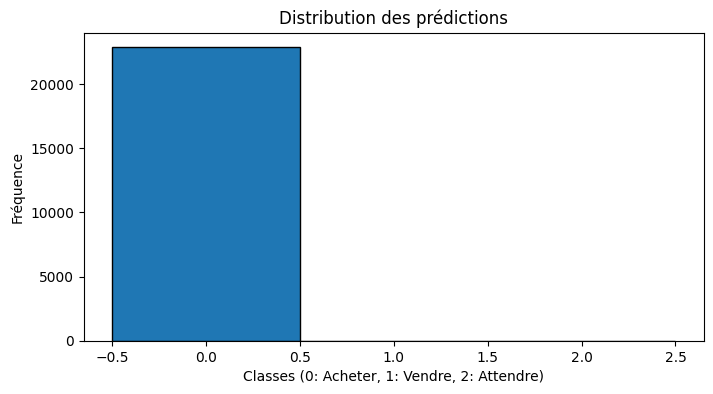

In [21]:
model.eval()
with torch.no_grad():
    outputs = model(X_batch)
    # Calculer les prédictions
    _, preds = torch.max(outputs, 1)
    
    # Visualiser par exemple la distribution des prédictions
    plt.figure(figsize=(8, 4))
    plt.hist(preds.numpy(), bins=np.arange(num_classes+1)-0.5, edgecolor='black')
    plt.xlabel("Classes (0: Acheter, 1: Vendre, 2: Attendre)")
    plt.ylabel("Fréquence")
    plt.title("Distribution des prédictions")
    plt.show()